C:\Users\luiz.melo\AppData\Local\Temp\ipykernel_8272\3991931103.py:98: RuntimeWarning: divide by zero encountered in log10
  axs[1, 1].plot(freqs, 20 * np.log10(np.abs(P_f) / np.max(np.abs(P_f))), color='darkgreen')


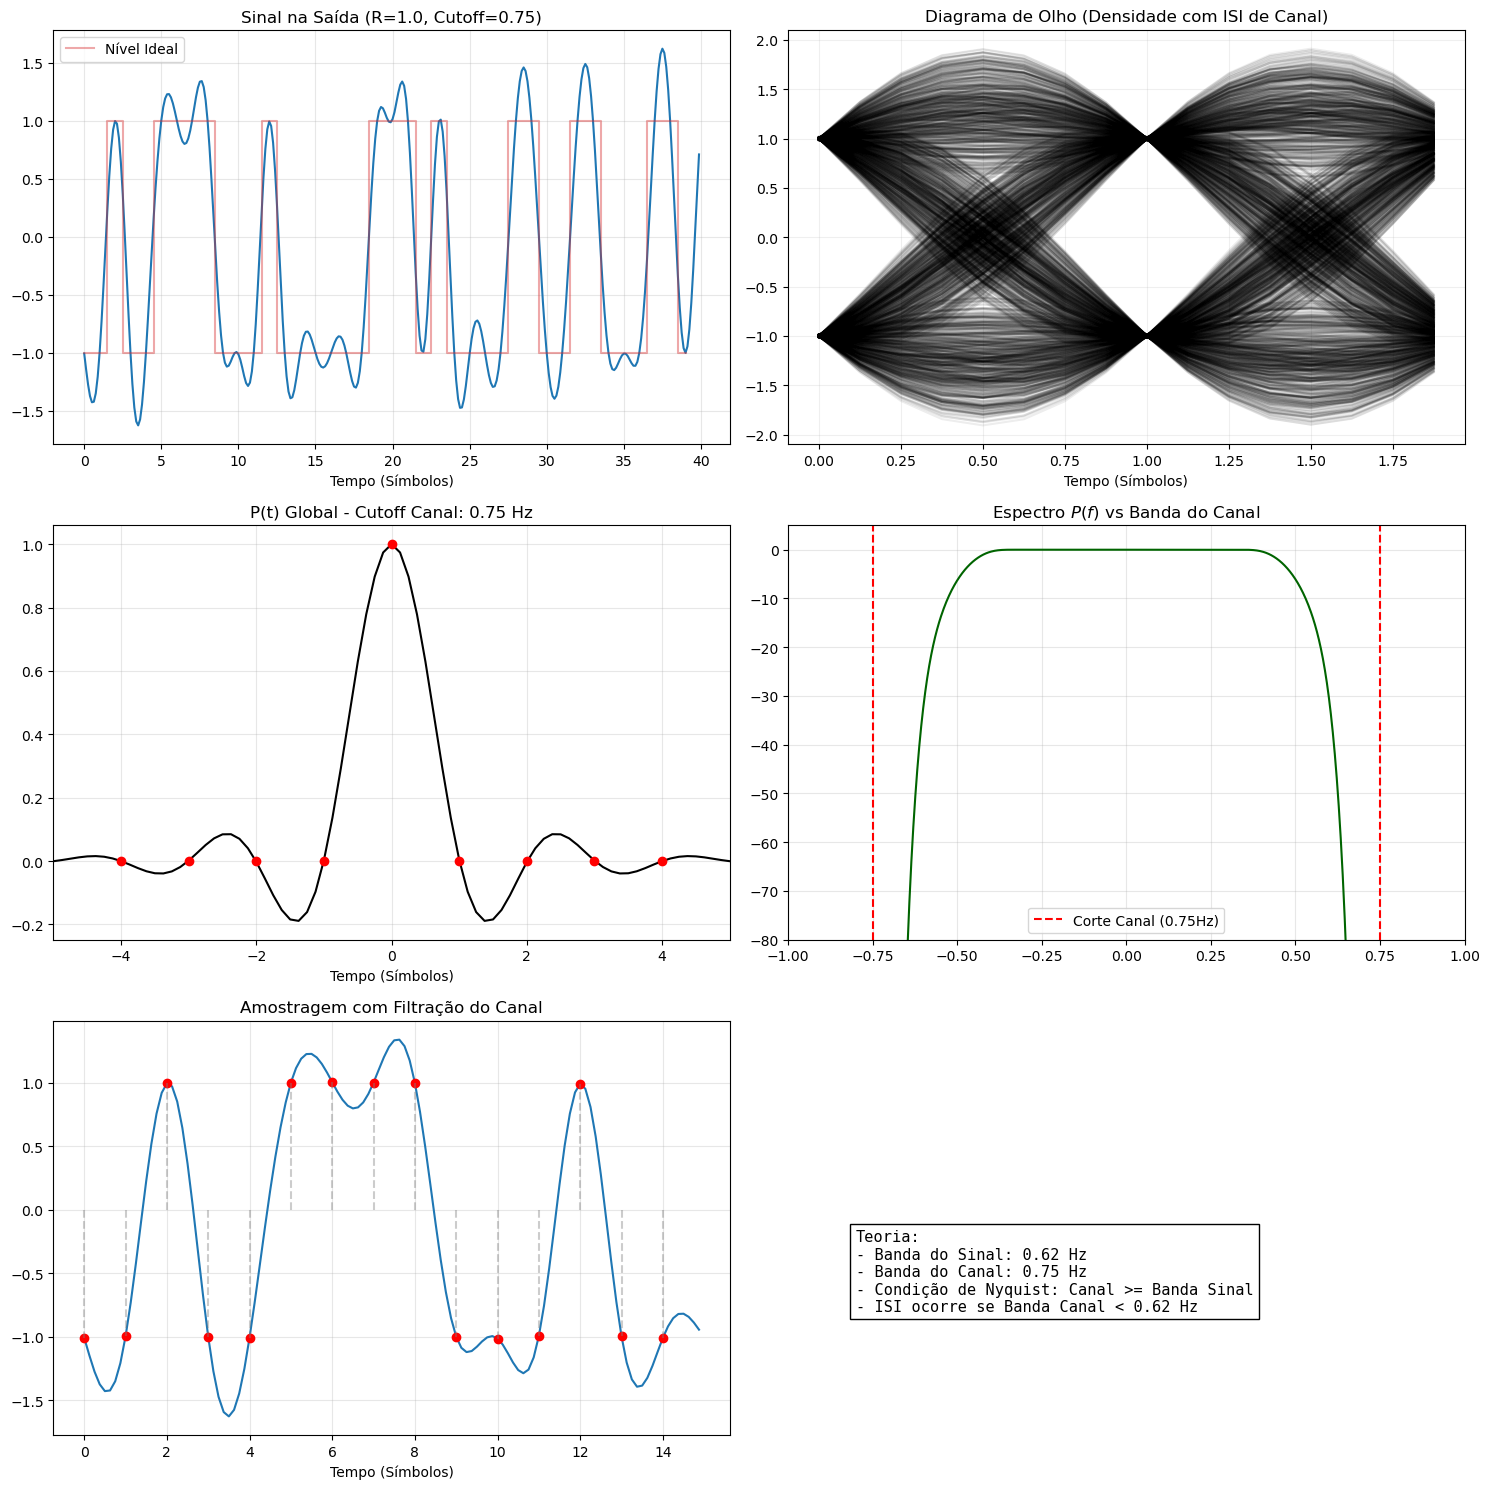

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- CONFIGURAÇÕES DO SISTEMA ---
M = 2               
sps = 8             
num_symbols = 5000  
rolloff = 0.25      
noise_on = False    
noise_var = 0.05    
filter_type = 'SRRC' 

# --- CONFIGURAÇÃO DO CANAL EM FUNÇÃO DA TAXA R ---
R = 1.0             # Taxa de símbolos (Símbolos por segundo)
fs = sps * R        # Taxa de amostragem do sistema
# Frequência de corte do canal
channel_cutoff = 0.75 * R 

# --- 1. GERAÇÃO DE SÍMBOLOS E UPSAMPLING ---
symbols = np.random.choice(np.arange(-(M-1), M, 2), num_symbols)
upsampled = np.zeros(num_symbols * sps)
upsampled[::sps] = symbols

# --- 2. DEFINIÇÃO DO FILTRO (Apenas SRRC) ---
def get_filter(ftype, sps, beta):
    span = 32 
    t = np.arange(-span/2 * sps, span/2 * sps + 1) / sps
    
    h = np.zeros(len(t))
    b = max(beta, 1e-9) 
    for i, ti in enumerate(t):
        if ti == 0: 
            h[i] = 1 - b + 4*b/np.pi
        elif abs(ti) == 1/(4*b):
            h[i] = (b/np.sqrt(2)) * ((1+2/np.pi)*np.sin(np.pi/(4*b)) + (1-2/np.pi)*np.cos(np.pi/(4*b)))
        else:
            num = np.sin(np.pi*ti*(1-b)) + 4*b*ti*np.cos(np.pi*ti*(1+b))
            den = np.pi*ti*(1-(4*b*ti)**2)
            h[i] = num / den
            
    h *= np.hamming(len(t))
    return h / np.sqrt(np.sum(h**2))

tx_filter = get_filter(filter_type, sps, rolloff)
rx_filter = tx_filter 

# --- 3. PROCESSAMENTO COM FILTRO DE CANAL ---
tx_signal = np.convolve(upsampled, tx_filter, mode='same')

# Canal: Filtro FIR Passa-Baixas
nyq_fs = fs / 2
h_channel = signal.firwin(101, channel_cutoff / nyq_fs, window='hamming')
chan_output = np.convolve(tx_signal, h_channel, mode='same')

rx_input = chan_output + (np.random.normal(0, np.sqrt(noise_var), len(chan_output)) if noise_on else 0)
rx_output = np.convolve(rx_input, rx_filter, mode='same')

# Resposta Global P(t) considerando o Canal
p_t_mid = np.convolve(tx_filter, h_channel, mode='full')
p_t = np.convolve(p_t_mid, rx_filter, mode='full')
t_p = (np.arange(len(p_t)) - len(p_t)//2) / sps

# --- 4. VISUALIZAÇÃO ---
fig, axs = plt.subplots(3, 2, figsize=(15, 15)) 

# A. FORMA DE ONDA (Eixo X dividido por sps)
time_axis_wf = np.arange(sps*40) / sps
axs[0, 0].plot(time_axis_wf, rx_output[len(rx_output)//2 : len(rx_output)//2 + sps*40], color='tab:blue')
axs[0, 0].step(np.arange(40), symbols[num_symbols//2:num_symbols//2+40], where='mid', color='tab:red', alpha=0.4, label='Nível Ideal')
axs[0, 0].set_title(f'Sinal na Saída (R={R}, Cutoff={channel_cutoff})')
axs[0, 0].set_xlabel('Tempo (Símbolos)')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# B. DIAGRAMA DE OLHO (Eixo X dividido por sps)
start, end = 100 * sps, len(rx_output) - 100 * sps
time_eye = np.arange(2*sps) / sps
for i in range(start, end - 2*sps, 2*sps):
    axs[0, 1].plot(time_eye, rx_output[i : i + 2*sps], color='black', alpha=0.07) 
axs[0, 1].set_title('Diagrama de Olho (Densidade com ISI de Canal)')
axs[0, 1].set_xlabel('Tempo (Símbolos)')
axs[0, 1].grid(True, alpha=0.2)

# C. RESPOSTA AO IMPULSO P(t)
axs[1, 0].plot(t_p, p_t / np.max(p_t), color='black', lw=1.5)
samples_pts = np.arange(-4, 5, 1)
axs[1, 0].plot(samples_pts, [1 if x==0 else 0 for x in samples_pts], 'ro', label='Instantes T')
axs[1, 0].set_title(f'P(t) Global - Cutoff Canal: {channel_cutoff} Hz')
axs[1, 0].set_xlim([-5, 5])
axs[1, 0].set_xlabel('Tempo (Símbolos)')
axs[1, 0].grid(True, alpha=0.3)

# D. RESPOSTA EM FREQUÊNCIA P(f)
N_fft = 4096
P_f = np.fft.fftshift(np.fft.fft(p_t, N_fft))
freqs = np.linspace(-fs/2, fs/2, N_fft)
axs[1, 1].plot(freqs, 20 * np.log10(np.abs(P_f) / np.max(np.abs(P_f))), color='darkgreen')
axs[1, 1].axvline(channel_cutoff, color='red', linestyle='--', label=f'Corte Canal ({channel_cutoff}Hz)')
axs[1, 1].axvline(-channel_cutoff, color='red', linestyle='--')
axs[1, 1].set_title('Espectro $P(f)$ vs Banda do Canal')
axs[1, 1].set_xlim([-R, R])
axs[1, 1].set_ylim([-80, 5])
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

# E. FORMA DE ONDA COM INSTANTES DE AMOSTRAGEM (ZOOM) (Eixo X dividido por sps)
num_view = 15 
start_idx = len(rx_output)//2
time_range = np.arange(num_view * sps) / sps
signal_segment = rx_output[start_idx : start_idx + num_view * sps]
sample_idx = np.arange(0, num_view * sps, sps) / sps
sample_vals = signal_segment[np.arange(0, num_view * sps, sps)]

axs[2, 0].plot(time_range, signal_segment, color='tab:blue', label='Sinal Contínuo')
axs[2, 0].plot(sample_idx, sample_vals, 'ro', label='Amostras')
axs[2, 0].vlines(sample_idx, 0, sample_vals, colors='gray', linestyles='--', alpha=0.4)
axs[2, 0].set_title('Amostragem com Filtração do Canal')
axs[2, 0].set_xlabel('Tempo (Símbolos)')
axs[2, 0].grid(True, alpha=0.3)

# F. RESUMO
axs[2, 1].axis('off')
axs[2, 1].text(0.1, 0.3, (f"Teoria:\n"
                          f"- Banda do Sinal: {(R/2)*(1+rolloff):.2f} Hz\n"
                          f"- Banda do Canal: {channel_cutoff:.2f} Hz\n"
                          f"- Condição de Nyquist: Canal >= Banda Sinal\n"
                          f"- ISI ocorre se Banda Canal < {(R/2)*(1+rolloff):.2f} Hz"), 
               fontsize=11, family='monospace', bbox=dict(facecolor='none', edgecolor='black'))

plt.tight_layout()
plt.show()